In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("house_data.csv")
df.head()


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [3]:
df.info()
print("Info Successfully loaded")
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Property_ID    300 non-null    str  
 1   Area           300 non-null    int64
 2   Bedrooms       300 non-null    int64
 3   Bathrooms      300 non-null    int64
 4   Age            300 non-null    int64
 5   Location       300 non-null    str  
 6   Property_Type  300 non-null    str  
 7   Price          300 non-null    int64
dtypes: int64(5), str(3)
memory usage: 18.9 KB
Info Successfully loaded


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


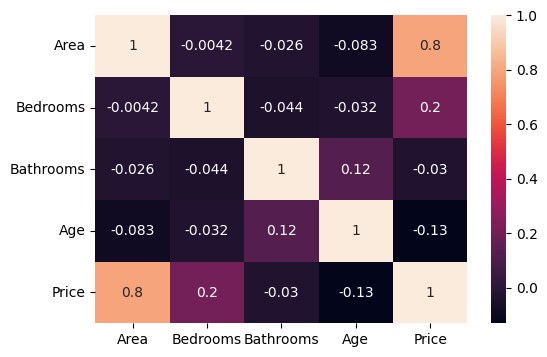

In [4]:
df.corr(numeric_only=True)
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [12]:
print(df.columns)

Index(['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Property_Type',
       'Price', 'Location_Rural', 'Location_Suburb'],
      dtype='str')


In [14]:
X = df.drop(["Price","Property_ID"],axis=1)
Y = df["Price"]

print(X.head())
print(Y.head())

   Area  Bedrooms  Bathrooms  Age Property_Type  Location_Rural  \
0  3712         4          3   36         House            True   
1  1591         4          1   35         House           False   
2  1646         4          3   20         Villa            True   
3  4814         1          2   13         Villa           False   
4   800         4          2   38     Apartment           False   

   Location_Suburb  
0            False  
1             True  
2            False  
3            False  
4             True  
0    22260000
1    16057500
2    12730000
3    50840000
4    10650000
Name: Price, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
X,
Y,
test_size = 0.2,
random_state = 42
)


In [20]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(240, 8)
(60, 8)
(240,)
(60,)


In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

In [23]:
print(model)

LinearRegression()


In [24]:
model.fit(X_train , Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
print("Intercept:",model.intercept_)
print("Coefficients:",model.coef_)

Intercept: 9180515.514387622
Coefficients: [ 7.55895649e+03  1.58570874e+06  4.54594038e+05 -8.24436799e+04
 -1.67281311e+07 -8.63301201e+06 -6.07903668e+05  6.37249726e+04]


In [27]:
predictions = model.predict(X_test)
print(predictions[:5])

[15074813.48326403 19163670.53037685 49321254.80756822 27009190.40108807
 21543273.97181161]


In [28]:
model.fit(X_train , Y_train)
predictions = model.predict(X_test)

print("Intercept:",model.intercept_)
print("Coefficients:",model.coef_)
print(predictions[:5])

Intercept: 9180515.514387622
Coefficients: [ 7.55895649e+03  1.58570874e+06  4.54594038e+05 -8.24436799e+04
 -1.67281311e+07 -8.63301201e+06 -6.07903668e+05  6.37249726e+04]
[15074813.48326403 19163670.53037685 49321254.80756822 27009190.40108807
 21543273.97181161]


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
mae = mean_absolute_error(Y_test , predictions)
mse = mean_squared_error(Y_test, predictions)

r2 = r2_score(Y_test, predictions)

print("MAE:",mae)
print("MSE:", mse)
print("R2 Score:",r2)

MAE: 2188736.343703811
MSE: 8454330868276.587
R2 Score: 0.9406371185112242


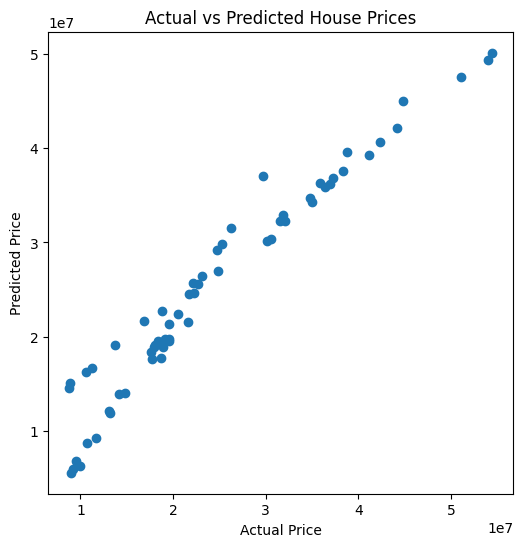

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(Y_test,predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.savefig("predictions_vs_actual.png")
plt.show()

In [32]:
from sklearn.tree import DecisionTreeRegressor

In [33]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [34]:
dt_predictions = dt_model.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

dt_mae = mean_absolute_error(Y_test, dt_predictions)
dt_mse = mean_squared_error(Y_test, dt_predictions)
dt_r2 = r2_score(Y_test,dt_predictions)
print("Decision Tree Results")
print("MAE:",dt_mae)
print("MSE:",dt_mse)
print("R2 Score:",dt_r2)

Decision Tree Results
MAE: 2280000.0
MSE: 9164761041666.666
R2 Score: 0.935648766050682


In [36]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, Y_train)
rf_predictions = rf_model.predict(X_test)

In [37]:
rf_mae = mean_absolute_error(Y_test,rf_predictions)
rf_mse = mean_squared_error(Y_test,rf_predictions)
rf_r2 = r2_score(Y_test, rf_predictions)

print("Random Forest Results")
print("MAE:",rf_mae)
print("MSE:",rf_mse)
print("R2 Score:",rf_r2)

Random Forest Results
MAE: 1493949.1666666667
MSE: 4120314726645.8335
R2 Score: 0.9710688215749718
